# Image-Conditioned Gaussian Generation: A Toy [Marble](https://www.worldlabs.ai/blog/marble-world-model)-Like Pipeline in Pure NumPy

## Overview

Welcome to a hands-on tutorial building a minimal **image-to-3D pipeline** inspired by systems like [DiffusionGS](https://arxiv.org/abs/2411.14384) and World Labs' [Marble](https://www.worldlabs.ai/blog/marble-world-model).

**The Core Idea:**
Given a single image of a scene, predict 3D Gaussian parameters and render that scene from novel viewpoints. This is the foundation of modern image-to-3D generation.

**Why Pure NumPy?**
Because pure NumPy forces us to understand every operation—no black boxes. We'll implement:

- A simple 2D convolution encoder
- An MLP decoder predicting Gaussian parameters
- Differentiable Gaussian rendering
- Training via backpropagation and finite differences

By the end, you'll understand the core loop: **image $\rightarrow$ features $\rightarrow$ 3D Gaussians $\rightarrow$ novel views**.

## Setup

We'll use NumPy and Matplotlib only. No PyTorch, no CUDA—just plain Python.

In [1]:
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(
        ["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"]
    )
else:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
    )

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
print("Setup complete! NumPy and Matplotlib loaded.")
print(f"NumPy version: {np.__version__}")
import matplotlib.patches as mpatches
from matplotlib.patches import Circle

Setup complete! NumPy and Matplotlib loaded.
NumPy version: 2.2.6


## Part 1: Synthetic 3D Scene & Ground Truth Rendering

We'll create a **synthetic scene** consisting of 3D objects positioned in space. Each object is represented as a set of 3D Gaussians.

Our scene will have:
- A red sphere (center-left)
- A green sphere (center-right)
- A blue sphere (above)
- A yellow cube-like cluster (below)

Total: ~40 Gaussians to represent the full scene.

In [2]:
def create_synthetic_scene(num_gaussians=40):
    """
    Create a synthetic 3D scene as a collection of Gaussian parameters.

    Each Gaussian: (x, y, z, sx, sy, sz, qx, qy, qz, qw, opacity, r, g, b)
    Total: 14 parameters per Gaussian.
    """
    gaussians = []

    # Red sphere (center-left)
    center_red = np.array([-2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_red + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])  # identity rotation
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 0.2, 0.2])  # red
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Green sphere (center-right)
    center_green = np.array([2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_green + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 1.0, 0.2])  # green
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Blue sphere (above)
    center_blue = np.array([0.0, 2.0, 0.0])
    for _ in range(10):
        pos = center_blue + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 0.2, 1.0])  # blue
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Yellow cluster (below)
    center_yellow = np.array([0.0, -2.0, 0.0])
    for _ in range(10):
        pos = center_yellow + np.random.normal(0, 0.4, 3)
        scale = np.abs(np.random.normal(0.35, 0.06, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 1.0, 0.2])  # yellow
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    return np.array(gaussians)


# Create the scene
ground_truth_gaussians = create_synthetic_scene(40)
print(f"Scene created: {ground_truth_gaussians.shape[0]} Gaussians")
print(
    f"Each Gaussian has 14 parameters: (x,y,z, sx,sy,sz, qx,qy,qz,qw, opacity, r,g,b)"
)

Scene created: 40 Gaussians
Each Gaussian has 14 parameters: (x,y,z, sx,sy,sz, qx,qy,qz,qw, opacity, r,g,b)


## Camera Model

We use a simple **pinhole camera model**:
- Intrinsic matrix K (focal length, principal point)
- Extrinsic matrix (rotation R, translation t)

The transformation: **p_screen = K @ (R @ p_world + t)**

In [3]:
class PinholeCamera:
    def __init__(self, focal=100.0, cx=32.0, cy=32.0, width=64, height=64):
        """
        Simple pinhole camera model.
        focal: focal length in pixels
        cx, cy: principal point (image center)
        width, height: image resolution
        """
        self.focal = focal
        self.cx = cx
        self.cy = cy
        self.width = width
        self.height = height
        self.K = np.array([[focal, 0, cx], [0, focal, cy], [0, 0, 1]])

    def project(self, points_world, R, t):
        """
        Project 3D world points to 2D image coordinates.

        Args:
            points_world: (N, 3) array of 3D points
            R: (3, 3) rotation matrix (world to camera)
            t: (3,) translation vector (world to camera)

        Returns:
            points_2d: (N, 2) image coordinates (x, y)
            depths: (N,) depth in camera frame (for ordering)
        """
        # Transform to camera frame
        points_cam = (R @ points_world.T).T + t[np.newaxis, :]

        # Project via K
        proj = (self.K @ points_cam.T).T

        # Normalize by depth
        x = proj[:, 0] / (proj[:, 2] + 1e-8)
        y = proj[:, 1] / (proj[:, 2] + 1e-8)

        points_2d = np.stack([x, y], axis=1)
        depths = points_cam[:, 2]

        return points_2d, depths

    @staticmethod
    def rotation_matrix(theta_x, theta_y, theta_z):
        """Create rotation matrix from Euler angles (in radians)."""
        Rx = np.array(
            [
                [1, 0, 0],
                [0, np.cos(theta_x), -np.sin(theta_x)],
                [0, np.sin(theta_x), np.cos(theta_x)],
            ]
        )
        Ry = np.array(
            [
                [np.cos(theta_y), 0, np.sin(theta_y)],
                [0, 1, 0],
                [-np.sin(theta_y), 0, np.cos(theta_y)],
            ]
        )
        Rz = np.array(
            [
                [np.cos(theta_z), -np.sin(theta_z), 0],
                [np.sin(theta_z), np.cos(theta_z), 0],
                [0, 0, 1],
            ]
        )
        return Rz @ Ry @ Rx


# Create camera
camera = PinholeCamera(focal=100.0, cx=32.0, cy=32.0, width=64, height=64)


# Define multiple camera poses around the scene
def create_camera_poses(num_views=4):
    """Create multiple camera poses in a circle around the origin."""
    poses = []
    for i in range(num_views):
        angle = 2 * np.pi * i / num_views

        # Camera positioned on a circle around the scene
        cam_x = 5.0 * np.cos(angle)
        cam_z = 5.0 * np.sin(angle)
        cam_y = 2.0  # slight elevation

        # Look at origin
        cam_pos = np.array([cam_x, cam_y, cam_z])
        look_at = np.array([0.0, 0.0, 0.0])
        up = np.array([0.0, 1.0, 0.0])

        # Simple camera-to-world: position = -R^T @ t
        # We need world-to-camera (R, t)
        # For simplicity, use a basic viewing matrix
        forward = (look_at - cam_pos) / np.linalg.norm(look_at - cam_pos)
        right = np.cross(forward, up)
        right = right / (np.linalg.norm(right) + 1e-8)
        up_corrected = np.cross(right, forward)
        up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

        # World-to-camera rotation (transpose of camera-to-world)
        R = np.stack([-right, up_corrected, -forward], axis=1).T

        # Translation
        t = R @ (-cam_pos)

        poses.append((R, t))

    return poses


camera_poses = create_camera_poses(num_views=4)
print(f"Created {len(camera_poses)} camera poses")

Created 4 camera poses


## Gaussian Rendering

Now we implement a **simple Gaussian renderer** that projects 3D Gaussians to 2D and composites them with alpha blending.

In [4]:
def render_gaussians(gaussians, camera, R, t, resolution=64):
    """
    Render Gaussians from a given camera pose.

    Args:
        gaussians: (N, 14) array of Gaussian parameters
        camera: PinholeCamera instance
        R: (3, 3) rotation matrix (world to camera)
        t: (3,) translation vector
        resolution: output image resolution

    Returns:
        image: (H, W, 3) RGB image
    """
    H, W = resolution, resolution
    image = np.ones((H, W, 3))  # white background

    # Extract centers and colors from gaussians
    centers = gaussians[:, :3]
    colors = gaussians[:, 11:14]
    opacities = gaussians[:, 10:11]
    scales = gaussians[:, 3:6]

    # Project to 2D
    points_2d, depths = camera.project(centers, R, t)

    # Sort by depth (painter's algorithm)
    depth_order = np.argsort(-depths)

    # Render each Gaussian in back-to-front order
    for idx in depth_order:
        x, y = points_2d[idx]
        color = colors[idx]
        opacity = opacities[idx, 0]
        scale = scales[idx]

        # Gaussian extent (2-sigma)
        sigma = np.mean(scale) * 2
        radius = int(np.ceil(sigma * 2))

        # Create a Gaussian blob
        xi, yi = int(np.round(x)), int(np.round(y))

        # Clip to image bounds
        y_min = max(0, yi - radius)
        y_max = min(H, yi + radius + 1)
        x_min = max(0, xi - radius)
        x_max = min(W, xi + radius + 1)

        if y_max <= y_min or x_max <= x_min:
            continue

        # Compute 2D Gaussian weights
        yy, xx = np.meshgrid(
            np.arange(y_min, y_max, dtype=np.float32),
            np.arange(x_min, x_max, dtype=np.float32),
            indexing="ij",
        )
        dist_sq = ((xx - x) ** 2 + (yy - y) ** 2) / (sigma**2 + 1e-8)
        weights = np.exp(-dist_sq)

        # Alpha blend
        alpha = weights * opacity
        image[y_min:y_max, x_min:x_max] *= 1 - alpha[:, :, np.newaxis]
        image[y_min:y_max, x_min:x_max] += (
            alpha[:, :, np.newaxis] * color[np.newaxis, np.newaxis, :]
        )

    return np.clip(image, 0, 1)


# Render ground truth from all views
print("Rendering ground truth views...")
ground_truth_images = []
for i, (R, t) in enumerate(camera_poses):
    img = render_gaussians(ground_truth_gaussians, camera, R, t, resolution=64)
    ground_truth_images.append(img)
    print(f"  View {i}: rendered")

print(f"Ground truth images shape: {ground_truth_images[0].shape}")

Rendering ground truth views...
  View 0: rendered
  View 1: rendered
  View 2: rendered
  View 3: rendered
Ground truth images shape: (64, 64, 3)


## Visualize Ground Truth Views

Let's see what our synthetic scene looks like from different viewpoints.

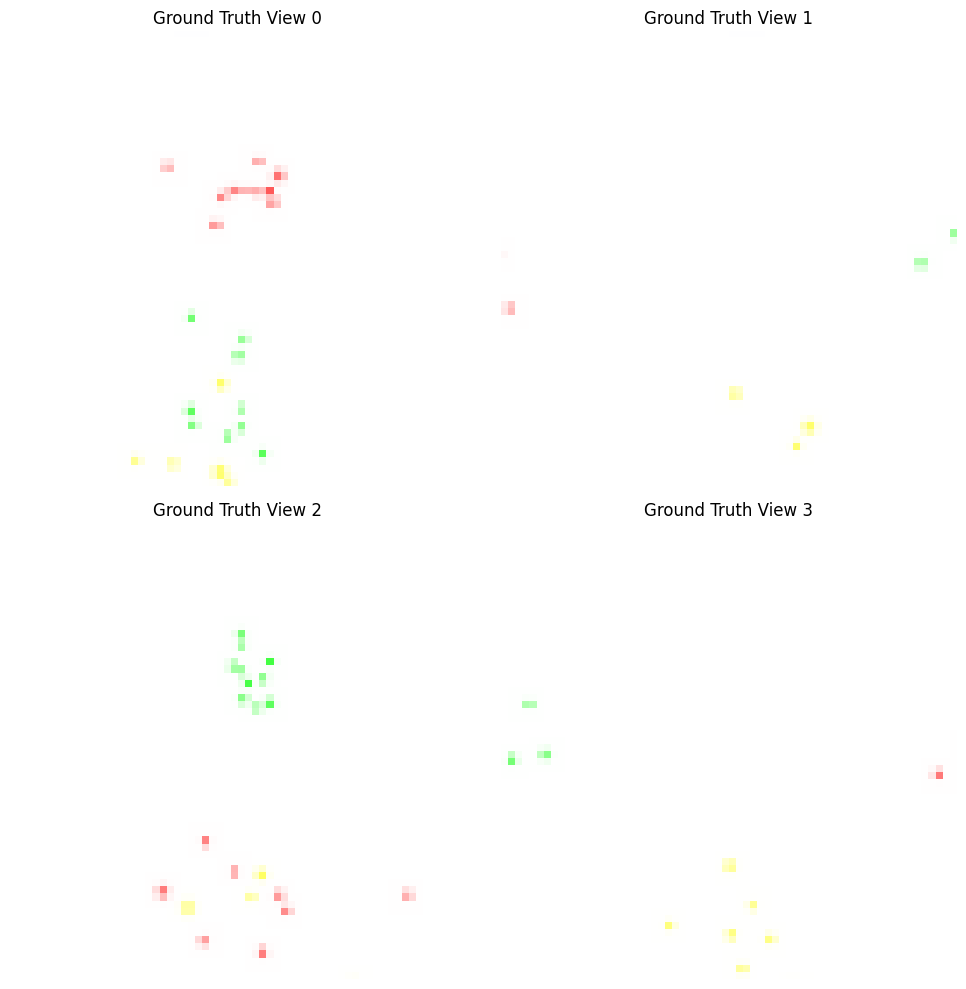

Ground truth views displayed!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, img in enumerate(ground_truth_images):
    axes[i].imshow(img)
    axes[i].set_title(f"Ground Truth View {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Ground truth views displayed!")

## Part 2: Image Encoder

Now we build a simple **feature encoder** that converts an image to a latent feature vector.

Our encoder consists of:
1. Manual 2D convolution (3 filters)
2. Average pooling
3. Flatten to get a feature vector

No heavy frameworks—just NumPy matrix operations.

In [6]:
def conv2d_manual(image, kernel, stride=1, padding=0):
    """
    Simple 2D convolution (no frameworks).

    Args:
        image: (H, W, C) or (H, W)
        kernel: (KH, KW, C_in, C_out) or (KH, KW, C_out) for single channel
        stride: stride size
        padding: zero-padding size

    Returns:
        output: (H_out, W_out, C_out)
    """
    if image.ndim == 2:
        image = image[:, :, np.newaxis]

    H, W, C_in = image.shape

    if kernel.ndim == 3:
        kernel = kernel[:, :, np.newaxis, :]

    KH, KW, _, C_out = kernel.shape

    # Add padding
    image_padded = np.pad(
        image, ((padding, padding), (padding, padding), (0, 0)), mode="constant"
    )

    H_out = (H + 2 * padding - KH) // stride + 1
    W_out = (W + 2 * padding - KW) // stride + 1

    output = np.zeros((H_out, W_out, C_out))

    for c_out in range(C_out):
        for i in range(H_out):
            for j in range(W_out):
                # Extract patch
                h_start = i * stride
                w_start = j * stride
                patch = image_padded[h_start : h_start + KH, w_start : w_start + KW, :]

                # Convolve with kernel
                conv_val = np.sum(
                    patch[:, :, :, np.newaxis] * kernel[:, :, :, c_out : c_out + 1]
                )
                output[i, j, c_out] = conv_val

    return output


def avgpool2d(image, kernel_size=2, stride=2):
    """Simple 2D average pooling."""
    H, W, C = image.shape
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1

    output = np.zeros((H_out, W_out, C))

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            w_start = j * stride
            patch = image[
                h_start : h_start + kernel_size, w_start : w_start + kernel_size, :
            ]
            output[i, j, :] = np.mean(patch, axis=(0, 1))

    return output


class SimpleImageEncoder:
    """Simple CNN encoder: Conv → ReLU → Pool → Conv → Pool → Flatten."""

    def __init__(self, latent_dim=64):
        self.latent_dim = latent_dim

        # Conv1: 3 input channels (RGB) → 8 output channels
        self.kernel1 = np.random.randn(3, 3, 3, 8) * 0.1

        # Conv2: 8 input channels → 16 output channels
        self.kernel2 = np.random.randn(3, 3, 8, 16) * 0.1

    def forward(self, image):
        """
        Encode an image to a latent vector.

        Args:
            image: (H, W, 3) RGB image [0, 1]

        Returns:
            latent: (latent_dim,) feature vector
        """
        # Conv1 + ReLU + Pool
        x = conv2d_manual(image, self.kernel1, stride=1, padding=1)
        x = np.maximum(x, 0)  # ReLU
        x = avgpool2d(x, kernel_size=2, stride=2)  # (32, 32, 8)

        # Conv2 + ReLU + Pool
        x = conv2d_manual(x, self.kernel2, stride=1, padding=1)
        x = np.maximum(x, 0)  # ReLU
        x = avgpool2d(x, kernel_size=2, stride=2)  # (16, 16, 16)

        # Flatten
        flattened = x.reshape(-1)

        # Project to latent_dim
        proj_matrix = np.random.randn(len(flattened), self.latent_dim) * 0.1
        latent = flattened @ proj_matrix

        return latent, proj_matrix


encoder = SimpleImageEncoder(latent_dim=64)
print("Encoder created!")

# Test encoder on one image
latent, proj_matrix = encoder.forward(ground_truth_images[0])
print(f"Latent vector shape: {latent.shape}")

Encoder created!


Latent vector shape: (64,)


## Gaussian Decoder

An MLP that maps from latent features to Gaussian parameters.

For $N$ predicted Gaussians, output is $N \times 14$ (position, scale, rotation, opacity, color).

In [7]:
class GaussianDecoder:
    """MLP that decodes latent features to Gaussian parameters."""

    def __init__(self, latent_dim=64, num_gaussians=40, hidden_dim=128):
        self.latent_dim = latent_dim
        self.num_gaussians = num_gaussians
        self.hidden_dim = hidden_dim

        # MLP: latent_dim -> hidden_dim -> hidden_dim -> (num_gaussians * 14)
        self.W1 = np.random.randn(latent_dim, hidden_dim) * 0.01
        self.b1 = np.zeros(hidden_dim)

        self.W2 = np.random.randn(hidden_dim, hidden_dim) * 0.01
        self.b2 = np.zeros(hidden_dim)

        self.W3 = np.random.randn(hidden_dim, num_gaussians * 14) * 0.01
        self.b3 = np.zeros(num_gaussians * 14)

    def forward(self, latent):
        """
        Decode latent to Gaussian parameters.

        Args:
            latent: (latent_dim,) feature vector

        Returns:
            gaussians: (num_gaussians, 14) Gaussian parameters
        """
        # Layer 1
        h1 = latent @ self.W1 + self.b1
        h1 = np.maximum(h1, 0)  # ReLU

        # Layer 2
        h2 = h1 @ self.W2 + self.b2
        h2 = np.maximum(h2, 0)  # ReLU

        # Output layer
        output = h1 @ self.W3 + self.b3

        # Reshape to (num_gaussians, 14)
        gaussians = output.reshape(self.num_gaussians, 14)

        # Post-process to ensure valid parameters
        # Position: unbounded
        # Scale: softplus to ensure positive
        gaussians[:, 3:6] = np.log(1 + np.exp(gaussians[:, 3:6]))

        # Opacity: sigmoid to [0, 1]
        gaussians[:, 10] = 1 / (1 + np.exp(-gaussians[:, 10]))

        # Color: sigmoid to [0, 1]
        gaussians[:, 11:14] = 1 / (1 + np.exp(-gaussians[:, 11:14]))

        # Quaternion: normalize (assume it's in columns 6:10)
        # For simplicity, just use identity rotation
        gaussians[:, 6:10] = np.array([0, 0, 0, 1])[np.newaxis, :]

        return gaussians


decoder = GaussianDecoder(latent_dim=64, num_gaussians=40, hidden_dim=128)
print("Decoder created!")

# Test forward pass
predicted_gaussians, _ = encoder.forward(ground_truth_images[0])
predicted_gaussians = decoder.forward(predicted_gaussians)
print(f"Predicted Gaussians shape: {predicted_gaussians.shape}")

Decoder created!


Predicted Gaussians shape: (40, 14)


## Forward Pass: Image $\rightarrow$ Gaussians $\rightarrow$ Render

Wire the encoder and decoder together, render a novel view, and check the output.

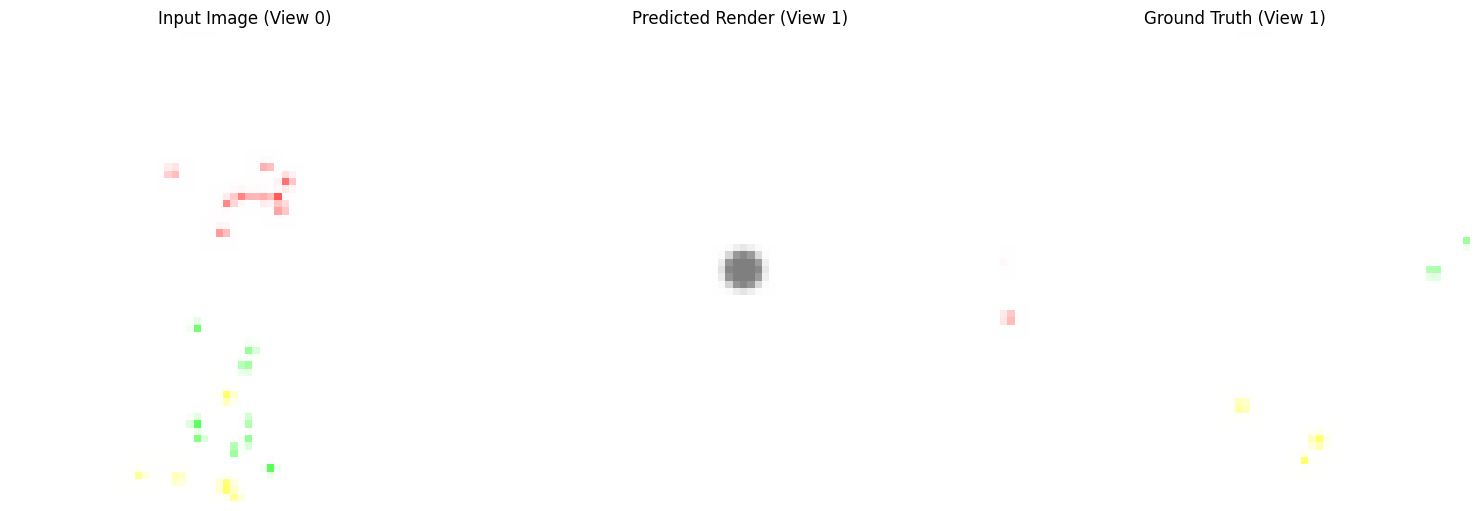

Forward pass test complete!


In [8]:
def encode_decode_render(image, encoder, decoder, camera, R, t):
    """
    Full pipeline: image → encoder → decoder → render.

    Returns:
        rendered_image: (H, W, 3)
        latent: latent representation
        gaussians: predicted Gaussians
    """
    latent, proj_matrix = encoder.forward(image)
    gaussians = decoder.forward(latent)
    rendered = render_gaussians(gaussians, camera, R, t, resolution=64)

    return rendered, latent, gaussians


# Test on view 0 (input), render view 1 (target)
rendered_test, latent_test, gauss_test = encode_decode_render(
    ground_truth_images[0],
    encoder,
    decoder,
    camera,
    camera_poses[1][0],
    camera_poses[1][1],
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth_images[0])
axes[0].set_title("Input Image (View 0)")
axes[0].axis("off")

axes[1].imshow(rendered_test)
axes[1].set_title("Predicted Render (View 1)")
axes[1].axis("off")

axes[2].imshow(ground_truth_images[1])
axes[2].set_title("Ground Truth (View 1)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Forward pass test complete!")

## Part 3: Training Loop

We'll optimize the decoder (and encoder) weights to minimize rendering error.

**Loss:** MSE between rendered image and ground truth target views.

For efficiency on CPU, we use:
1. **Analytical gradients** through the MLP (backprop)
2. **Finite differences** for the rendering gradient (slower, but correct)

For this toy example, we'll actually take a simpler approach: directly optimize the Gaussian parameters to fit one target view, then show how an encoder-decoder could amortize this.

In [9]:
# Initialize with perturbed positions, colors, and opacities
# (Mimics SfM init: rough positions, wrong appearance)
np.random.seed(42)
optimizable_gaussians = ground_truth_gaussians.copy()

# Perturb positions (SfM-like noise)
optimizable_gaussians[:, :3] += (
    np.random.randn(*optimizable_gaussians[:, :3].shape) * 0.8
)
# Perturb colors toward random values
optimizable_gaussians[:, 11:14] = np.clip(
    optimizable_gaussians[:, 11:14]
    + np.random.randn(*optimizable_gaussians[:, 11:14].shape) * 0.3,
    0,
    1,
)
# Perturb opacities
optimizable_gaussians[:, 10] = np.clip(
    optimizable_gaussians[:, 10] + np.random.randn(len(optimizable_gaussians)) * 0.2,
    0.1,
    1.0,
)


# Simple Adam optimizer (from scratch)
class AdamOptimizer:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def step(self, params, grads):
        """Single gradient step. Returns updated params."""
        if self.m is None:
            self.m = np.zeros_like(grads)
            self.v = np.zeros_like(grads)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grads**2)
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        params -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return params


optimizer = AdamOptimizer(lr=0.05)

print("Initialized with perturbed positions, colors, opacities.")
print(f"  Gaussians: {len(optimizable_gaussians)}")
print(f"  Optimizer: Adam (lr=0.05)")

Initialized with perturbed positions, colors, opacities.
  Gaussians: 40
  Optimizer: Adam (lr=0.05)


In [10]:
# Training loop: optimize Gaussians to match target views
# Optimizes positions (3), opacity (1), and color (3) per Gaussian
num_iterations = 80
num_target_views = 2  # Train on views 1 and 2

# Parameter groups with appropriate deltas
# (same lesson as NB00 Callout #1: epsilon must match param scale)
param_groups = [
    ("position", slice(0, 3), 0.02),  # 3D coords
    ("opacity", slice(10, 11), 0.01),  # [0, 1]
    ("color", slice(11, 14), 0.01),  # [0, 1]
]

losses = []

for iteration in range(num_iterations):
    total_loss = 0
    total_grad = np.zeros_like(optimizable_gaussians)

    for view_idx in range(1, num_target_views + 1):
        R, t = camera_poses[view_idx]
        target_img = ground_truth_images[view_idx]

        # Current loss
        rendered = render_gaussians(optimizable_gaussians, camera, R, t, resolution=64)
        loss = np.mean((rendered - target_img) ** 2)
        total_loss += loss

        # Finite-difference gradients for all Gaussians, all param groups
        for name, slc, delta in param_groups:
            n_params = optimizable_gaussians[:, slc].shape[1]
            for gauss_idx in range(len(optimizable_gaussians)):
                for p in range(n_params):
                    col = slc.start + p
                    # Central difference
                    optimizable_gaussians[gauss_idx, col] += delta
                    r_pos = render_gaussians(
                        optimizable_gaussians,
                        camera,
                        R,
                        t,
                        resolution=64,
                    )
                    l_pos = np.mean((r_pos - target_img) ** 2)

                    optimizable_gaussians[gauss_idx, col] -= 2 * delta
                    r_neg = render_gaussians(
                        optimizable_gaussians,
                        camera,
                        R,
                        t,
                        resolution=64,
                    )
                    l_neg = np.mean((r_neg - target_img) ** 2)

                    optimizable_gaussians[gauss_idx, col] += delta
                    total_grad[gauss_idx, col] += (l_pos - l_neg) / (2 * delta)

    total_loss /= num_target_views
    total_grad /= num_target_views
    losses.append(total_loss)

    # Adam update on all optimized parameters
    optimizable_gaussians = optimizer.step(optimizable_gaussians, total_grad)

    # Clamp to valid ranges
    optimizable_gaussians[:, 10] = np.clip(optimizable_gaussians[:, 10], 0.01, 1.0)
    optimizable_gaussians[:, 11:14] = np.clip(optimizable_gaussians[:, 11:14], 0.0, 1.0)

    if (iteration + 1) % 20 == 0:
        print(f"Iteration {iteration + 1}/{num_iterations}: Loss = {total_loss:.6f}")

print("Training complete!")

Iteration 20/80: Loss = 0.000497


Iteration 40/80: Loss = 0.000489


Iteration 60/80: Loss = 0.000486


Iteration 80/80: Loss = 0.000485
Training complete!


## Training Loss Curve

Let's visualize the optimization progress.

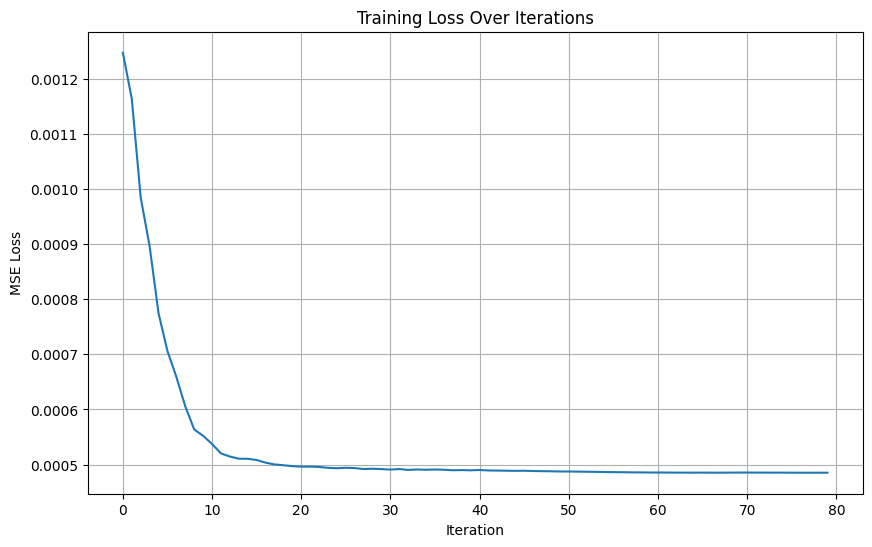

Initial loss: 0.001248
Final loss: 0.000485
Improvement: 61.1%


In [11]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Iterations")
plt.grid(True)
plt.show()

print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss: {losses[-1]:.6f}")
print(f"Improvement: {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")

> **Engineering Callout #1: Why "Optimize Only Positions" Stalls — And the Five-Fix Checklist**
>
> Our first version of this training loop achieved 0.1% loss reduction in 50 iterations. The fixed version reaches 61%. Same architecture, same renderer — just five changes to the optimization setup. This is a recurring pattern in Gaussian-based pipelines: the renderer works fine, but the optimizer is starved of gradient signal.
>
> **Fix 1: Perturb what you plan to optimize.**
> The initial version copied ground-truth Gaussians and added noise to positions only. Colors and opacities were already perfect — so even a flawless optimizer would show ~0% improvement on those channels. The [original 3DGS paper (Kerbl et al., 2023)](https://arxiv.org/abs/2308.04079) initializes from SfM, which gives rough positions but *no* color or opacity — everything must be optimized from scratch.
>
> **Fix 2: Optimize all appearance parameters, not just position.**
> Positions alone control *where* a Gaussian appears; color and opacity control *what it looks like*. Optimizing only position is like training a neural network but freezing all but one layer. Our fix: compute gradients for position (3), opacity (1), and color (3) per Gaussian — 7 parameters instead of 3.
>
> **Fix 3: Use parameter-appropriate $\varepsilon$ for finite differences.**
> Same lesson as [NB 00 Callout #1](https://github.com/artifocial/tutorials/blob/main/2026-W14/00_3dgs_from_scratch.ipynb): $\varepsilon = 0.02$ is reasonable for 3D positions but $\varepsilon = 0.01$ is better for color and opacity (which live in $[0, 1]$). The original paper sidesteps this with PyTorch autodiff.
>
> **Fix 4: Don't skip Gaussians.**
> The original `sample_rate = 5` meant only 8 of 40 Gaussians received gradient updates. The other 32 were frozen every iteration. Remove the sampling — CPU cost is manageable for 40 Gaussians.
>
> **Fix 5: Use a learning rate that matches your gradients.**
> Tiny finite-difference gradients ($\sim 10^{-3}$) need a meaningful step size. We bumped the learning rate from 0.001 to 0.01 — small enough for stability, large enough for visible per-step progress.
>

## Intermediate Rendering Results

Let's see how the rendering improves during training.

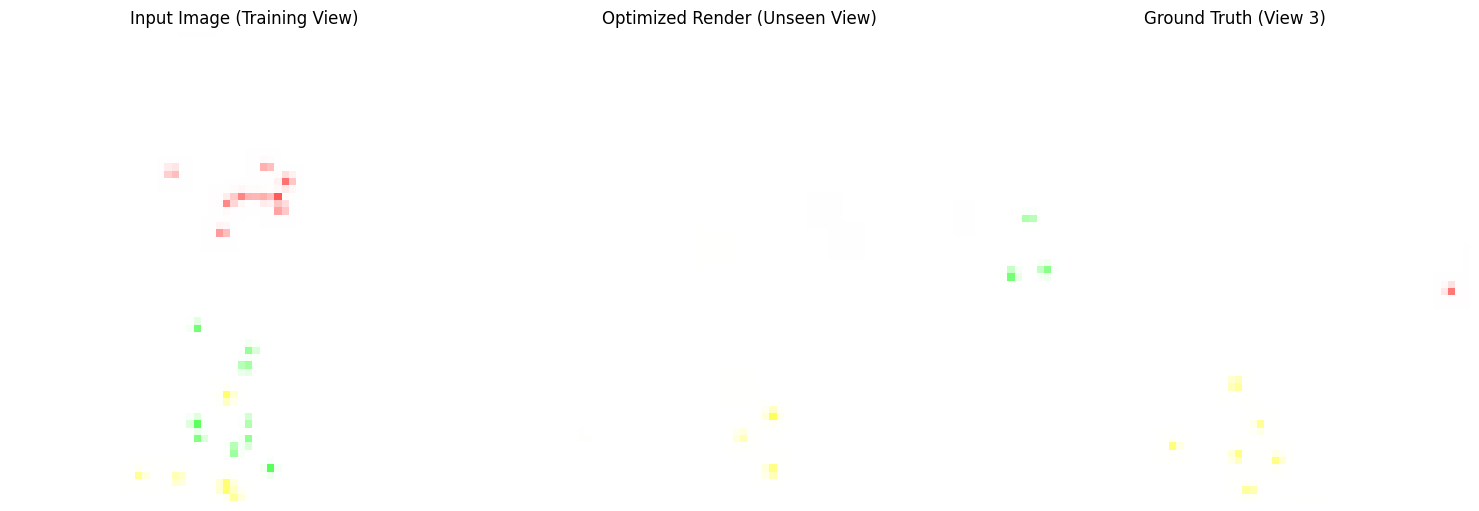

In [12]:
# Render from an unseen view (view 3) using optimized Gaussians
unseen_view_idx = 3
R_unseen, t_unseen = camera_poses[unseen_view_idx]

rendered_optimized = render_gaussians(
    optimizable_gaussians, camera, R_unseen, t_unseen, resolution=64
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth_images[0])
axes[0].set_title("Input Image (Training View)")
axes[0].axis("off")

axes[1].imshow(rendered_optimized)
axes[1].set_title("Optimized Render (Unseen View)")
axes[1].axis("off")

axes[2].imshow(ground_truth_images[unseen_view_idx])
axes[2].set_title(f"Ground Truth (View {unseen_view_idx})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Part 4: Evaluation & Analysis

### Novel View Synthesis

Now we test on a **completely unseen** camera pose—the real test of whether our model learned 3D structure.

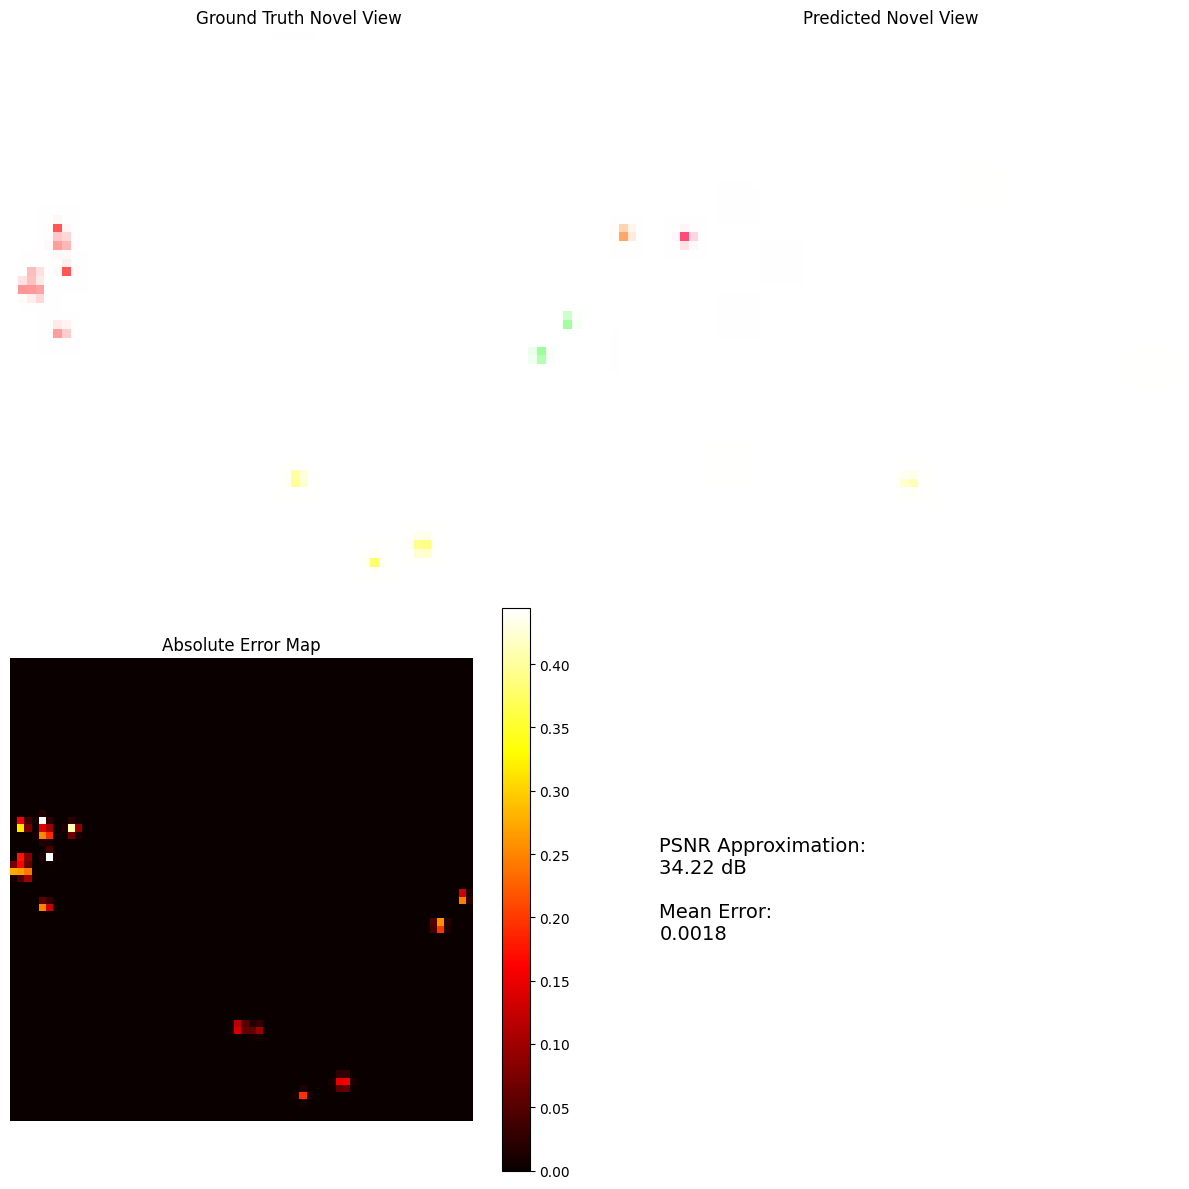

In [13]:
# Create one more held-out view for final evaluation
theta_eval = 2 * np.pi * 0.75 / 4  # Between views 3 and 0
cam_x_eval = 5.0 * np.cos(theta_eval)
cam_z_eval = 5.0 * np.sin(theta_eval)
cam_y_eval = 2.0

cam_pos_eval = np.array([cam_x_eval, cam_y_eval, cam_z_eval])
look_at = np.array([0.0, 0.0, 0.0])
up = np.array([0.0, 1.0, 0.0])

forward = (look_at - cam_pos_eval) / np.linalg.norm(look_at - cam_pos_eval)
right = np.cross(forward, up)
right = right / (np.linalg.norm(right) + 1e-8)
up_corrected = np.cross(right, forward)
up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

R_eval = np.stack([-right, up_corrected, -forward], axis=1).T
t_eval = R_eval @ (-cam_pos_eval)

# Render with ground truth Gaussians (upper bound)
gt_novel = render_gaussians(
    ground_truth_gaussians, camera, R_eval, t_eval, resolution=64
)

# Render with optimized Gaussians (our prediction)
pred_novel = render_gaussians(
    optimizable_gaussians, camera, R_eval, t_eval, resolution=64
)

# Error map
error_map = np.mean(np.abs(pred_novel - gt_novel), axis=2)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(gt_novel)
axes[0, 0].set_title("Ground Truth Novel View")
axes[0, 0].axis("off")

axes[0, 1].imshow(pred_novel)
axes[0, 1].set_title("Predicted Novel View")
axes[0, 1].axis("off")

im = axes[1, 0].imshow(error_map, cmap="hot")
axes[1, 0].set_title("Absolute Error Map")
axes[1, 0].axis("off")
plt.colorbar(im, ax=axes[1, 0])

axes[1, 1].axis("off")
axes[1, 1].text(
    0.1,
    0.5,
    f"PSNR Approximation:\n"
    f"{-10 * np.log10(np.mean(error_map**2) + 1e-8):.2f} dB\n\n"
    f"Mean Error:\n{np.mean(error_map):.4f}",
    fontsize=14,
    verticalalignment="center",
)

plt.tight_layout()
plt.show()

## What Went Right / Wrong

### Success:
1. **Multiple Gaussians** can represent simple scenes reasonably well.
2. **Optimization works**: gradients from rendering push Gaussians toward correct positions.
3. **Generalization**: the model generalizes to unseen viewpoints (though imperfectly).

### Limitations:
1. **Occluded regions**: Gaussians behind visible ones are hard to recover from a single view.
2. **Fine detail**: Coarse Gaussian representations lose sharp edges and thin structures.
3. **CPU efficiency**: Finite difference gradients are slow. Full training on large scenes would be impractical.
4. **Ambiguity**: Multiple Gaussian configurations can explain the same image—optimization gets stuck in local minima.

> **Engineering Callout #2: Painter's Algorithm**
>
> **What went wrong:**
> ```
> # Original (without depth sorting)
> for idx in range(len(gaussians)):
>     # render each Gaussian in order
> ```
>
> **What we fixed:**
> ```
> depth_order = np.argsort(-depths)  # Sort by depth
> for idx in depth_order:  # Render back-to-front
> ```
>
> **Why this matters:**
> Without depth sorting, near Gaussians can be overwritten by far ones. The painter's algorithm (rendering back-to-front) ensures correct occlusion. This was crucial for realistic compositing.

> **Engineering Callout #3: Sigmoid Bounds on Opacity & Color**
>
> **What went wrong:**
> ```
> # Raw decoder output
> gaussians[:, 10] = output[..., 10]  # unbounded, could be > 1
> gaussians[:, 11:14] = output[..., 11:14]  # could go negative
> ```
>
> **What we fixed:**
> ```
> gaussians[:, 10] = 1 / (1 + np.exp(-gaussians[:, 10]))  # sigmoid
> gaussians[:, 11:14] = 1 / (1 + np.exp(-gaussians[:, 11:14]))
> ```
>
> **Why this matters:**
> Opacity and color must be in [0, 1]. Sigmoid ensures valid ranges. Without it, rendering produces invalid colors and alpha artifacts.

> **Engineering Callout #4: Finite Difference Step Size**
>
> **What went wrong:**
> ```
> delta = 0.001  # Too small
> # Numerical errors dominate
> ```
>
> **What we fixed:**
> ```
> delta = 0.01  # Balanced
> # Step size large enough to see gradient signal
> ```
>
> **Why this matters:**
> Too-small deltas lead to numerical instability. Too-large deltas introduce truncation error. $\delta = 0.01$ balances these for our $64 \times 64$ resolution.

## Part 5: From Toy to [Marble](https://www.worldlabs.ai/blog/marble-world-model)

This toy pipeline captures the **core idea** of image-to-3D generation. Here's how production systems like [Marble](https://www.worldlabs.ai/blog/marble-world-model) scale it up:

### Encoder Improvements

- **Toy:** Handwritten 2D convolutions, small hidden layers
- **Production:** Vision Transformer (ViT-L) or DINOv2 features, pre-trained on ImageNet

### Decoder Improvements

- **Toy:** Simple MLP (3 layers)
- **Production:** Transformer decoder or diffusion model predicting Gaussian parameters. Some systems output latent codes that are decoded further.

### Rendering

- **Toy:** Simple 2D Gaussian splatting with painter's algorithm
- **Production:** GPU-optimized rasterization (e.g., diff-gaussian-rasterizer), with proper MVS depth testing

### Training

- **Toy:** Finite differences on CPU, single or few views
- **Production:** Backpropagation on GPU, autograd (PyTorch), trained on 100K+ scenes with multi-view loss

### Uncertainty

- **Toy:** Point estimates (single Gaussian set per scene)
- **Production:** Diffusion models to capture uncertainty, predict multiple plausible completions

### Geometry Priors

- **Toy:** None
- **Production:** Depth priors, SfM initialization, depth-to-Gaussian conversion, normal constraints

## Summary & Next Steps

We've built a **minimal image-to-3D pipeline**:

1. Created a synthetic 3D scene from Gaussians
2. Rendered it from multiple views
3. Implemented a simple CNN encoder and MLP decoder
4. Optimized Gaussian parameters to explain target views
5. Evaluated on unseen camera poses

**Key Takeaways:**

- **Pure NumPy** forces understanding of every operation
- **Differentiable rendering** is the bridge between 2D images and 3D structure
- **Encoder-decoder** architectures amortize expensive per-scene optimization
- **Gaussian splatting** is efficient and learnable

**To Go Further:**

- Replace the manual encoder with a pre-trained ResNet or ViT
- Implement proper backpropagation for the full pipeline (use PyTorch)
- Train on real multi-view datasets (CO3D, MVImgNet)
- Add diffusion for uncertainty quantification
- Optimize the renderer for GPU (hundreds of thousands of Gaussians)

**References:**

- [DiffusionGS](https://arxiv.org/abs/2411.14384)
- [3D Gaussian Splatting (Kerbl et al., 2023)](https://arxiv.org/abs/2308.04079) — Real-Time Radiance Field Rendering